In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor

In [3]:
df_raw = pd.read_csv('dataset.csv', na_values=['\\N', 'N/A', 'null'], low_memory=False)
# טעינת קובץ של הבמאים 
df_crew = pd.read_csv('title.crew.tsv.gz', sep='\t', usecols=['tconst', 'directors'], low_memory=False)
# מיזוג של הקבצים 
df_raw = pd.merge(df_raw, df_crew, on='tconst', how='left')

In [4]:
def clean_and_split(val):
    # אם יש רשימה ריקה נחזיר נל ואם לא אז את הרשימה
    if isinstance(val, list):
        return val if len(val) > 0 else np.nan
    # התנאי הראשי: אם חסר, או שיש מילות זבל/רווח ריק - מחזירים NULL
    if pd.isna(val) or str(val).strip().lower() in ['nan', 'none', 'null', '\\n', '[]', '']:
        return np.nan    
    # הופכים לטקסט
    text = str(val)
    # מעיפים החוצה סוגריים וגרשיים מכל הסוגים
    clean_text = text.replace('[', '').replace(']', '').replace("'", "").replace('"', '')
    # מפצלים לפי פסיק, ומוודאים שאין רווחים מיותרים לפני או אחרי המילה
    result = [word.strip() for word in clean_text.split(',') if word.strip()]
    # וידוא אחרון: אם אחרי כל הפיצולים נשארנו עם רשימה ריקה, נחזיר NULL
    return result if len(result) > 0 else np.nan
def _get_actors_experience(df):
    """חישוב ממוצע הופעות השחקנים בעבר"""
    temp_df = df[['startYear', 'lead_actors_ids']].dropna().copy()
    exploded = temp_df.explode('lead_actors_ids')   
    counts = pd.crosstab(exploded['lead_actors_ids'], exploded['startYear']).cumsum(axis=1)
    def _calc_row(row):
        year, actors = row['startYear'], row['lead_actors_ids']
        if pd.isna(year) or not isinstance(actors, list) or len(actors) == 0:
            return np.nan
        target_year = min(max(int(year) - 1, counts.columns.min()), counts.columns.max())
        valid_years = counts.columns[counts.columns <= target_year]
        if len(valid_years) == 0: return 0.0
        past_counts = [counts.at[a, valid_years.max()] if a in counts.index else 0 for a in actors]
        return np.mean(past_counts)
    return df.apply(_calc_row, axis=1)

def _get_director_stats(df):
    """חישוב ממוצע דירוגי עבר וסימון במאי חדש """
    temp_df = df[['startYear', 'directors', 'averageRating']].dropna().copy()
    stats = temp_df.groupby(['directors', 'startYear']).agg(
        sum=('averageRating', 'sum'), count=('averageRating', 'count')).reset_index()
    r_pivot = stats.pivot(index='directors', columns='startYear', values='sum').fillna(0).cumsum(axis=1)
    c_pivot = stats.pivot(index='directors', columns='startYear', values='count').fillna(0).cumsum(axis=1)
    
    def _calc_row(row):
        dir_id, year = row['directors'], row['startYear']
        if pd.isna(dir_id) or pd.isna(year) or dir_id not in r_pivot.index:
            return 0.0, 1.0
        valid_years = r_pivot.columns[r_pivot.columns <= (int(year) - 1)]
        if len(valid_years) == 0: return 0.0, 1.0
        target = valid_years.max()
        p_sum, p_count = r_pivot.at[dir_id, target], c_pivot.at[dir_id, target]
        return (p_sum / p_count, 0.0) if p_count > 0 else (0.0, 1.0)
    return df.apply(_calc_row, axis=1)

In [5]:
def prepare_data(df):
    processed_df = df.copy()
    # מחיקת עמודות אסורות
    processed_df = processed_df.drop(columns=['numVotes', 'BoxOffice'], errors='ignore')
    #  ניקוי והמרת עמודות מספריות 
    for col in ['startYear', 'runtimeMinutes', 'budget']:
        if col in processed_df.columns:
            extracted = processed_df[col].astype(str).str.strip().str.extract(r'(\d+(?:\.\d+)?)')[0]
            processed_df[col] = pd.to_numeric(extracted, errors='coerce')
    # טיפול ברשימות ובטקסטים
    for col in ['genres', 'lead_actors_ids']:
        if col in processed_df.columns:
            processed_df[col] = processed_df[col].apply(clean_and_split)
            
    for col in ['tconst', 'primaryTitle', 'Language', 'Country', 'plot']:
        if col in processed_df.columns:
            processed_df[col] = processed_df[col].apply(
                lambda x: str(x) if pd.notna(x) and str(x).strip().lower() not in ['nan', 'none', 'null', '\\n'] else np.nan)
            
    #  הוספת פיצ'רים 1-5 
    if 'lead_actors_ids' in processed_df.columns and 'startYear' in processed_df.columns:
        processed_df['avg_actors_past_experience'] = _get_actors_experience(processed_df)
        
    if 'genres' in processed_df.columns and 'runtimeMinutes' in processed_df.columns:
        # פיצר 2: יחס אורך לחציון הז'אנר
        exploded = processed_df[['runtimeMinutes', 'genres']].dropna().explode('genres')
        medians = exploded.groupby('genres')['runtimeMinutes'].median()
        processed_df['relative_runtime_by_genre'] = processed_df.apply(
            lambda r: np.mean([r['runtimeMinutes'] / medians[g] for g in r['genres'] if g in medians and medians[g] > 0])
            if isinstance(r['genres'], list) and pd.notna(r['runtimeMinutes']) else np.nan, axis=1)
            
    if 'genres' in processed_df.columns: # פיצר 3
        processed_df['num_genres'] = processed_df['genres'].apply(lambda x: len(x) if isinstance(x, list) else np.nan)
        
    if 'runtimeMinutes' in processed_df.columns: # פיצר 4
        processed_df['is_too_short'] = processed_df['runtimeMinutes'].apply(lambda x: 1.0 if x < 75 else (0.0 if pd.notna(x) else np.nan))
        processed_df['is_too_long'] = processed_df['runtimeMinutes'].apply(lambda x: 1.0 if x > 150 else (0.0 if pd.notna(x) else np.nan))
        
    if 'directors' in processed_df.columns and 'startYear' in processed_df.columns and 'averageRating' in processed_df.columns: # פיצר 5
        dir_features = _get_director_stats(processed_df)
        processed_df['director_past_avg'] = [x[0] for x in dir_features]
        processed_df['is_new_director'] = [x[1] for x in dir_features]
        
    return processed_df

In [6]:
df_new = df_raw.copy()
processed_df = prepare_data(df_new)
#  מוחקים רק את השורות שבהן אין לנו את משתנה המטרה 
processed_df = processed_df.dropna(subset=['averageRating'])
y = processed_df['averageRating']
# מגדירים אילו עמודות אסור שייכנסו למודל
cols_to_drop_from_X = [
    'averageRating',    
    'tconst',           
    'primaryTitle',     
    'plot',             
    'directors',        
    'lead_actors_ids',  
    'genres',           
    'Language',         
    'Country']
#  מגדירים את X
X = processed_df.drop(columns=cols_to_drop_from_X, errors='ignore')
print("Columns in X:", list(X.columns))
print(f"Number of rows after dropping missing y: {len(X)}")

Columns in X: ['startYear', 'runtimeMinutes', 'budget', 'avg_actors_past_experience', 'relative_runtime_by_genre', 'num_genres', 'is_too_short', 'is_too_long', 'director_past_avg', 'is_new_director']
Number of rows after dropping missing y: 115560


In [7]:
print("---  בניית המודלים וביצוע Tuning ---")

# --- מודל 1: Elastic Net (כולל Pipeline ו-Tuning) ---
elastic_net_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler()),                 
    ('model', ElasticNet(random_state=42, max_iter=5000))])

param_grid_en = {
    'model__alpha': [0.01, 0.1, 1.0, 10.0],
    'model__l1_ratio': [0.2, 0.5, 0.8]}

# מריצים את ה-Tuning כדי למצוא את הפרמטרים הטובים ביותר למודל 1
print("מבצע Tuning ל-Elastic Net...")
grid_search_en = GridSearchCV(
    estimator=elastic_net_pipeline,
    param_grid=param_grid_en,
    cv=10, # שימוש ב-CV למציאת הפרמטרים
    scoring='neg_mean_squared_error',
    n_jobs=-1)
grid_search_en.fit(X, y)

# שומרים את המודל המנצח של Elastic Net בצד
best_elastic_net_model = grid_search_en.best_estimator_
print(f"הפרמטרים הטובים ביותר שנמצאו ל-Elastic Net: {grid_search_en.best_params_}")

# --- מודל 2: Random Forest (כולל Pipeline) ---
print("מגדיר את מודל ה-Random Forest...")
random_forest_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler()),                 
    ('model', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1))])

---  בניית המודלים וביצוע Tuning ---
מבצע Tuning ל-Elastic Net...
הפרמטרים הטובים ביותר שנמצאו ל-Elastic Net: {'model__alpha': 0.01, 'model__l1_ratio': 0.8}
מגדיר את מודל ה-Random Forest...


In [8]:
print("\n--- הערכת מודלים (10-Fold CV) ---")

# פונקציית עזר להדפסת המדדים כפי שהמרצה ביקש
def display_cv_results(model_name, cv_results):
    rmse_scores = -cv_results['test_rmse']
    mae_scores = -cv_results['test_mae']
    r2_scores = cv_results['test_r2']
    
    print(f"\n======== מדדי ביצוע: {model_name} ========")
    print(f"RMSE: ממוצע = {rmse_scores.mean():.4f}, סטיית תקן = {rmse_scores.std():.4f}")
    print(f"MAE:  ממוצע = {mae_scores.mean():.4f}, סטיית תקן = {mae_scores.std():.4f}")
    print(f"R²:   ממוצע = {r2_scores.mean():.4f}, סטיית תקן = {r2_scores.std():.4f}")

# הגדרת המדדים שאנחנו רוצים למדוד
scoring_metrics = {
    'rmse': 'neg_root_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'r2': 'r2'}

# 1. הערכת מודל Elastic Net המכויל
print("מעריך את ה-Elastic Net...")
cv_results_en = cross_validate(
    best_elastic_net_model, X, y, cv=10, scoring=scoring_metrics, return_train_score=False
)
display_cv_results("Elastic Net (Tuned)", cv_results_en)

# 2. הערכת מודל Random Forest
print("מעריך את ה-Random Forest...")
cv_results_rf = cross_validate(
    random_forest_pipeline, X, y, cv=10, scoring=scoring_metrics, return_train_score=False
)
display_cv_results("Random Forest", cv_results_rf)


--- הערכת מודלים (10-Fold CV) ---
מעריך את ה-Elastic Net...

======== מדדי ביצוע: Elastic Net (Tuned) ========
RMSE: ממוצע = 1.2006, סטיית תקן = 0.0533
MAE:  ממוצע = 0.9271, סטיית תקן = 0.0459
R²:   ממוצע = 0.1335, סטיית תקן = 0.0257
מעריך את ה-Random Forest...

======== מדדי ביצוע: Random Forest ========
RMSE: ממוצע = 1.1385, סטיית תקן = 0.0502
MAE:  ממוצע = 0.8687, סטיית תקן = 0.0399
R²:   ממוצע = 0.2207, סטיית תקן = 0.0235


In [9]:
from sklearn.model_selection import cross_val_predict

#  הפקת תחזיות חסינות זליגה לכל הסרטים באמצעות המודל המנצח (Random Forest)
print("מפיק תחזיות עבור כל הסרטים באמצעות Random Forest...")
y_pred = cross_val_predict(random_forest_pipeline, X, y, cv=10, n_jobs=-1)

# יצירת דאטהפרים חדש לצורך ניתוח השגיאות
error_df = processed_df.copy()
error_df['predicted_rating'] = y_pred
error_df['actual_rating'] = y
#  חישוב השגיאה הסטטיסטית 
error_df['error'] = error_df['predicted_rating'] - error_df['actual_rating']
#  חילוץ 10 הסרטים עם ה-Overprediction הכי גבוה (המודל החמיא להם סתם)
# שגיאה חיובית גדולה = המודל חזה גבוה, הציון האמיתי נמוך
over_predictions = error_df.sort_values(by='error', ascending=False).head(10)

#  חילוץ 10 הסרטים עם ה-Underprediction הכי גבוה (המודל קטל אותם סתם)
# שגיאה שלילית גדולה = המודל חזה נמוך, הציון האמיתי גבוה
under_predictions = error_df.sort_values(by='error', ascending=True).head(10)
#  הדפסת התוצאות בצורה נוחה כדי שתוכלי להעתיק את השמות לדוח
print("\nתצוגת 10 סרטי Overprediction (המודל חזה גבוה מדי):")
print(over_predictions[['primaryTitle', 'startYear', 'actual_rating', 'predicted_rating', 'error']])

print("\nתצוגת 10 סרטי Underprediction (המודל חזה נמוך מדי):")
print(under_predictions[['primaryTitle', 'startYear', 'actual_rating', 'predicted_rating', 'error']])

מפיק תחזיות עבור כל הסרטים באמצעות Random Forest...

תצוגת 10 סרטי Overprediction (המודל חזה גבוה מדי):
                                             primaryTitle  startYear  \
133563             Horseplay: The History of Horse Riding     2021.0   
16815                                                Kurz     2023.0   
67854                                      Alone Together     2014.0   
79701            Vixen Highway 2006: It Came from Uranus!     2010.0   
48587                                      Proud American     2008.0   
84225                                          Zoo School     2019.0   
75730                                         Tuberkulose     2007.0   
81307                                    We Love Bad Boys     2024.0   
104680  Brush with Life: The Art of Being Edward Biberman     2007.0   
4301                                     Izzie's Way Home     2016.0   

        actual_rating  predicted_rating     error  
133563            1.0          7.095250  6.095250  

In [10]:
# נפיק תחזיות גם עבור ה-Elastic Net
y_pred_en = cross_val_predict(best_elastic_net_model, X, y, cv=10, n_jobs=-1)

# נצור דאטהפרים לשגיאות של ה-Elastic Net
error_df_en = processed_df.copy()
error_df_en['error'] = y_pred_en - y
error_df_en['primaryTitle'] = processed_df['primaryTitle'] # וודאי שהשם קיים

# במקום להשתמש ב-iloc שצריך מיקומים (0,1,2...), נשתמש ב-loc שמתייחס לשמות האינדקסים
top_rf_outliers = error_df.loc[abs(error_df['error']).nlargest(20).index]
top_en_outliers = error_df_en.loc[abs(error_df_en['error']).nlargest(20).index]

# מציאת החפיפה
overlap = set(top_rf_outliers.index).intersection(set(top_en_outliers.index))
print(f"מספר הסרטים המשותפים (חפיפה) ב-Outliers של שני המודלים: {len(overlap)}")

מספר הסרטים המשותפים (חפיפה) ב-Outliers של שני המודלים: 6


5 הז'אנרים הנפוצים ביותר שנמצאו לניתוח: ['Drama', 'Comedy', 'Romance', 'Action', 'Documentary']

--- טבלת ביצועים לפי ז'אנר ---
      Genre     RMSE      MAE  Count
      Drama 1.045853 0.801320  58460
     Comedy 1.105240 0.840809  33316
    Romance 0.987776 0.751624  15693
     Action 1.195968 0.911153  13987
Documentary 1.162638 0.895448  13014


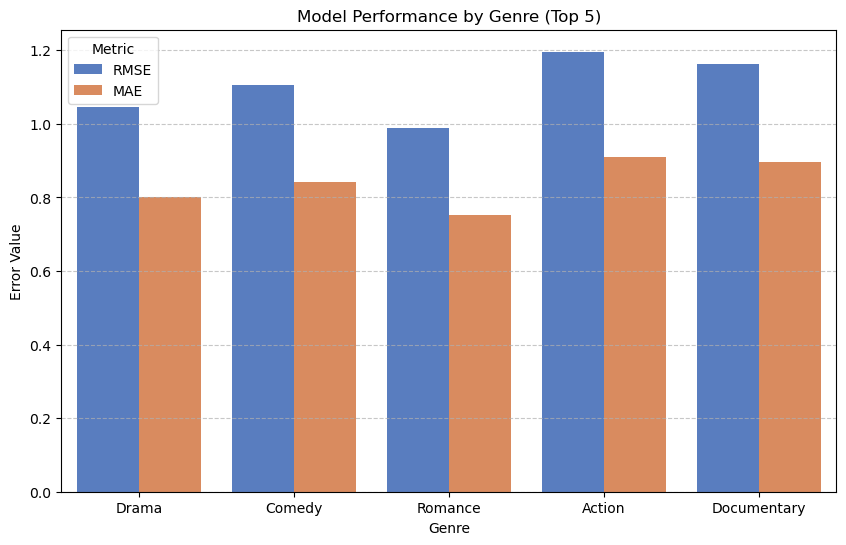

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error

# פונקציית עזר לחישוב מדדים עבור תת-קבוצה
def calculate_metrics(df_subset):
    if len(df_subset) == 0:
        return None, None
    rmse = np.sqrt(mean_squared_error(df_subset['actual_rating'], df_subset['predicted_rating']))
    mae = mean_absolute_error(df_subset['actual_rating'], df_subset['predicted_rating'])
    return rmse, mae

#  פירוק רשימת הז'אנרים ומציאת 5 הנפוצים ביותר 
all_genres = error_df['genres'].dropna().explode()
top_5_genres = all_genres.value_counts().head(5).index.tolist()
print(f"5 הז'אנרים הנפוצים ביותר שנמצאו לניתוח: {top_5_genres}")
genre_results = []
#  חישוב מדדים לכל ז'אנר בנפרד
for genre in top_5_genres:
    # סינון חכם שמתאים לבדיקה האם האלמנט קיים בתוך הרשימה של השורה
    genre_subset = error_df[error_df['genres'].apply(lambda x: genre in x if isinstance(x, list) else False)]
    rmse, mae = calculate_metrics(genre_subset)
    if rmse is not None:
        genre_results.append({
            'Genre': genre,
            'RMSE': rmse,
            'MAE': mae,
            'Count': len(genre_subset)})

genre_results_df = pd.DataFrame(genre_results)
print("\n--- טבלת ביצועים לפי ז'אנר ---")
print(genre_results_df.to_string(index=False))

# ציור גרף ברים מקובץ לז'אנרים
genre_melted = genre_results_df.melt(id_vars='Genre', value_vars=['RMSE', 'MAE'], var_name='Metric', value_name='Score')
plt.figure(figsize=(10, 6))
sns.barplot(data=genre_melted, x='Genre', y='Score', hue='Metric', palette='muted')
plt.title("Model Performance by Genre (Top 5)")
plt.ylabel("Error Value")
plt.xlabel("Genre")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


3 העשורים שנבחרו לניתוח: ['2000s', '2010s', '2020s']

--- טבלת ביצועים לפי עשור יציאה ---
Decade     RMSE      MAE  Count
 2000s 1.189423 0.912950  17555
 2010s 1.239786 0.949988  33605
 2020s 1.290099 0.991957  18405


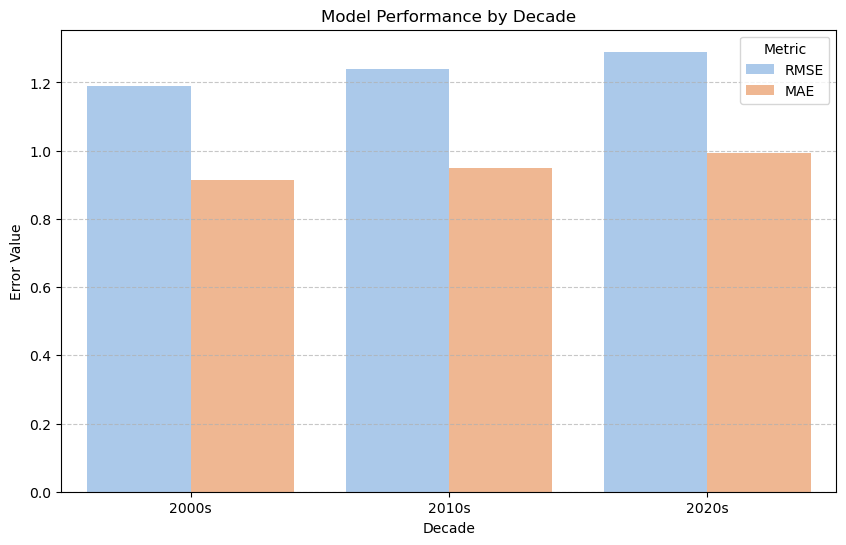

In [12]:
# יצירת עמודת עשור מתוך startYear הקיים במחברת
error_df['decade'] = (error_df['startYear'] // 10 * 10).dropna().astype(int).astype(str) + 's'
# בחירת 3 העשורים הנפוצים ביותר בדאטה
top_3_decades = sorted(error_df['decade'].dropna().value_counts().head(3).index.tolist())
print(f"\n3 העשורים שנבחרו לניתוח: {top_3_decades}")
decade_results = []
# חישוב מדדים לכל עשור בנפרד
for decade in top_3_decades:
    decade_subset = error_df[error_df['decade'] == decade]
    rmse, mae = calculate_metrics(decade_subset)
    if rmse is not None:
        decade_results.append({
            'Decade': decade,
            'RMSE': rmse,
            'MAE': mae,
            'Count': len(decade_subset)})

decade_results_df = pd.DataFrame(decade_results)
print("\n--- טבלת ביצועים לפי עשור יציאה ---")
print(decade_results_df.to_string(index=False))

# ציור גרף ברים מקובץ לעשורים
decade_melted = decade_results_df.melt(id_vars='Decade', value_vars=['RMSE', 'MAE'], var_name='Metric', value_name='Score')
plt.figure(figsize=(10, 6))
sns.barplot(data=decade_melted, x='Decade', y='Score', hue='Metric', palette='pastel')
plt.title("Model Performance by Decade")
plt.ylabel("Error Value")
plt.xlabel("Decade")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()